# Tahap 0 — Bekukan Substrat

**Tujuan**: menghilangkan cacat formulasi reward & lingkungan yang dapat mengaburkan atau
membatalkan perbandingan metode, lalu **mengunci** konfigurasi bersama. Setelah tahap ini
lulus gerbang, **tidak boleh ada perubahan substrat** — bila terjadi, seluruh tahap
berikutnya yang sudah dijalankan harus diulang.

**Sifat**: tanpa training. Seluruhnya verifikasi kode & pengukuran murah (hitungan menit).

**Navigasi Eksekusi_RL**: **[Tahap 0]** → [Tahap 1](01_Tetapkan_Rezim.ipynb) → [Tahap 2](02_Replikasi_Baseline_PDQN.ipynb) → [Tahap 3](03_Eksperimen_Pivot.ipynb) → [Tahap 4](04_Solusi_RRM_Arsitektur.ipynb) → [Tahap 5](05_Robustness_Stabilitas.ipynb) → [Tahap 6](06_Pelaporan.ipynb)

Dokumen rujukan: `../Dokumen_Penting/Rencana_Eksekusi_Penelitian.md` (rencana lengkap), `../Dokumen_Penting/Rumusan_Masalah_Teknis_RL.md` (rumusan masalah & keputusan desain), `../Dokumen_Penting/Metodologi_Perbandingan_PDQN_RRM.md` (aturan atribusi).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath(".."))
import common
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.precision", 4)
ROOT = common.ROOT
print("ROOT:", ROOT)
print("Substrat saat ini:", common.SUBSTRAT)

ROOT: C:\Users\Lenovo\Documents\Tesis\Repo\Custom SImulation
Substrat saat ini: {'dataset_kanonik': 'scenario_dataset_klaster12.json', 'willingness_ratio': None, 'willingness_radius_km': None, 'horizon_days': 30, 'dt_minutes': 15.0, 'n_spklu': 6, 'tau': 0.68, 'beku_pada': None}


## 0.1 Dekomposisi reward — ukur ketimpangan skala antar-suku

Baseline (sebelum perbaikan apa pun): suku global \|mean\| **0,3195** vs objektif sejati
(`wait`) \|mean\| **0,0233** → rasio **13,7×**. Target: rasio ≤ **3×**, fraksi anti-herding
aktif ≥ **50%**, fraksi reward ter-atribusi ke aksi sendiri ≥ **25%**.

Dijalankan dengan `HPPOPolicy` BELUM TERLATIH (disengaja) — mengukur sifat struktural
reward, bukan hasil optimasi.

In [2]:
summary = common.reward_decomposition(seed=0, k=2)
for k, v in summary.items():
    print(f"{k:12s} {v}")

rasio_skala = abs(summary["global"]["mean"]) / max(abs(summary["wait"]["mean"]), 1e-9)
print(f"\nRasio |mean| suku global vs objektif sejati (wait): {rasio_skala:.1f}x  (target <= 3x)")
print(f"Fraksi anti-herding aktif: {summary['flocking']['frac_active']*100:.1f}%  (target >= 50%)")
print(f"Fraksi objektif sejati (wait) nonzero: {summary['wait']['frac_nonzero']*100:.1f}%")
print(f"Fraksi transisi UNRESOLVED (trainer episodik, tanpa filter): "
     f"{100*summary['resolusi']['unresolved']/summary['resolusi']['total']:.1f}%")

prox         {'n': 1313, 'mean': 0.09205416265609624, 'std': 0.014973815778215894, 'frac_nonzero': 1.0}
gini         {'n': 992, 'mean': -0.3523345554721563, 'std': 0.11711892757109349, 'frac_nonzero': 0.907258064516129}
flock        {'n': 1313, 'mean': -0.39374714394516375, 'std': 0.35397617835842027, 'frac_nonzero': 0.8933739527798934}
wait         {'n': 1298, 'mean': 1.1485029153158037, 'std': 1.5110937116198866, 'frac_nonzero': 0.6417565485362096}
global       {'mean': -0.74608169941732, 'note': 'mean gini+flock (n berbeda scr desain, lihat komentar)'}
total        {'n': 1313, 'mean': 0.47935296363587926, 'std': 1.3834303110548405}
flocking     {'frac_active': 0.8933739527798934, 'mean': 1.3124904798172126}
konkurensi   {'frac_1_keputusan': 0.7469758064516129, 'mean_per_step_aktif': 1.3235887096774193}
resolusi     {'total': 1313, 'resolved': 1298, 'unresolved': 15}

Rasio |mean| suku global vs objektif sejati (wait): 0.6x  (target <= 3x)
Fraksi anti-herding aktif: 89.3%  (target >=

**Catatan implementasi** (lihat `marl_spklu/rl/rewards.py` &
`Dokumen_Penting/Rumusan_Masalah_Teknis_RL.md` §3.2b untuk detail akar penyebab):
- Akar ketimpangan skala: `wait_scale=60` membagi objektif sejati dengan 60, sementara suku
  Gini TIDAK diskalakan sama sekali. **Perbaikan yang disarankan**: samakan orde besaran
  (mis. naikkan `alpha_wait` atau turunkan `alpha_gini`/tambah faktor skala Gini eksplisit),
  lalu ukur ulang sel di atas sampai rasio ≤3×.
- Ganti Gini **sesaat** → Gini **rolling 24 jam** pada `global_reward` (menurunkan derau
  eksogen, std sesaat terukur 0,287).
- Ganti anti-herding jendela **per-langkah** → **bergulir** (mis. `sim.recent_recs`, 24 jam).

Implementasikan perbaikan ini di `marl_spklu/rl/rewards.py` (atau turunan
`RewardCalculator` baru), lalu jalankan ulang sel di atas sampai kriteria terpenuhi.

In [3]:
# PERBAIKAN DITERAPKAN di marl_spklu/rl/rewards.py: RewardCalculator.seimbang()/.individual()/
# .kumulatif() -- lihat sel di bawah utk verifikasi & rasional lengkap (delta-Gini, prox
# dikecualikan dari penyeimbangan std).

## 0.1b Tiga preset reward terkalibrasi

**Temuan yang mengoreksi rencana semula**: std MENTAH kelima suku (prox, gini, flock,
improvement, honesty) ternyata sudah sebanding (0,09–0,26) — yang timpang adalah **mean**,
didominasi `gini` level absolut (mean mentah ~−0,62, hampir konstan tiap keputusan, bukan
sinyal ttg keputusan tertentu). Diubah jadi **delta-Gini** (perubahan Gini antar keputusan,
bukan level) → mean→0 (secara desain), std tetap sebanding → BISA diseimbangkan lewat bobot.
`prox` (mean mentah 0,84, std 0,13 — rasio mean/std tinggi, struktural hampir konstan)
sengaja **dikecualikan** dari penyeimbangan std (menaikkannya akan meledakkan mean-nya),
dipertahankan sbg suku minor tetap (`beta_prox=0,1`) di ketiga preset.

**RE-KALIBRASI (setelah anti-herding dipindah ke jendela bergulir, §0.1c di bawah)**: std
mentah `flock` naik ~2x lipat (0,132 → 0,280) drpd definisi per-langkah lama, krn kini
dihitung per-KEPUTUSAN dari `sim.recent_recs` (jendela 24 jam) bukan per-langkah. Ketiga
preset di bawah SUDAH memakai bobot hasil kalibrasi ULANG thd statistik baru ini.

Tiga preset (`marl_spklu/rl/rewards.py::RewardCalculator.seimbang/.individual/.kumulatif`)
menata ulang HANYA rasio bobot **individual** (wait improvement + honesty) vs **global**
(gini-delta + flocking) -- mengikuti struktur `R_i = R_individual + R_global` yang memang
sudah didesain sejak awal di kelas ini:

| Preset | Target std individual | Target std global | Filosofi |
|---|---|---|---|
| `seimbang()` | ~0,15 | ~0,15 | Netral, tak ada kanal dominan |
| `individual()` | ~0,20 | ~0,08 | RL diprioritaskan memperbaiki wait/kejujuran PER pengguna |
| `kumulatif()` | ~0,08 | ~0,20 | RL diprioritaskan pemerataan sistem & anti-herding |

**Koreksi metrik verifikasi**: kriteria awal "rasio \|mean\| ≤3×" tidak berlaku lagi utk
delta-Gini (mean≈0 by design → rasio-terhadap-mean meledak tak berarti). Diverifikasi
berbasis **std** (variansi) -- itu yg sebenarnya menentukan kontribusi tiap suku pada arah
gradien PPO (via advantage), bukan level rata-rata mentah.

In [4]:
from marl_spklu.rl.rewards import RewardCalculator

preset_rows = []
for name, factory in [("lama (belum diperbaiki)", lambda: RewardCalculator()),
                      ("seimbang", RewardCalculator.seimbang),
                      ("individual", RewardCalculator.individual),
                      ("kumulatif", RewardCalculator.kumulatif)]:
    s = common.reward_decomposition(seed=0, k=2, reward_calc=factory())
    preset_rows.append(dict(preset=name, prox_mean=s["prox"]["mean"], prox_std=s["prox"]["std"],
                            global_mean=s["global"]["mean"],
                            wait_mean=s["wait"]["mean"], wait_std=s["wait"]["std"],
                            total_std=s["total"]["std"],
                            flocking_aktif_pct=s["flocking"]["frac_active"]*100,
                            unresolved=s["resolusi"]["unresolved"]))

df_preset = pd.DataFrame(preset_rows)
common.save_json(preset_rows, "00_reward_presets.json")
display(df_preset)

print()
print("Catatan v2: kolom 'wait' kini murni improvement (alpha_honesty sudah dihapus dari")
print("ruang aksi & reward -- EstWait selalu jujur). 'global' tak lagi punya std tunggal yg")
print("valid (gini & flock kini n berbeda scr desain) -- lihat dekomposisi 4-suku di bawah.")

,preset,prox_mean,prox_std,global_mean,wait_mean,wait_std,total_std,flocking_aktif_pct,unresolved
0,lama (belum diperbaiki),0.0895,0.0145,-0.6112,0.3492,0.8044,0.7831,87.4334,5
1,seimbang,0.0927,0.0144,-0.1615,0.1038,0.1321,0.2198,89.4897,17
2,individual,0.0900,0.0147,-0.0685,0.0587,0.1194,0.1519,87.3572,9
3,kumulatif,0.0900,0.0144,-0.1684,0.0173,0.0383,0.2816,87.2810,1



Catatan v2: kolom 'wait' kini murni improvement (alpha_honesty sudah dihapus dari
ruang aksi & reward -- EstWait selalu jujur). 'global' tak lagi punya std tunggal yg
valid (gini & flock kini n berbeda scr desain) -- lihat dekomposisi 4-suku di bawah.


In [5]:
five_way_rows = []
for name, factory in [("seimbang", RewardCalculator.seimbang),
                      ("individual", RewardCalculator.individual),
                      ("kumulatif", RewardCalculator.kumulatif)]:
    r = common.reward_five_way(factory(), seed=0, k=2)
    row = {"preset": name, "frac_varians_individual_pct": r["_frac_varians_individual"]*100}
    for term in ("prox", "gini", "flock", "improvement"):
        row[f"{term}_mean"] = r[term]["mean"]
        row[f"{term}_std"] = r[term]["std"]
    five_way_rows.append(row)

df_five = pd.DataFrame(five_way_rows)
common.save_json(five_way_rows, "00_reward_five_way.json")
display(df_five[["preset", "frac_varians_individual_pct"] +
               [f"{t}_std" for t in ("prox","gini","flock","improvement")]])

print()
print("Target: seimbang ~50% | individual >>25% | kumulatif boleh <25% (disengaja)")
for row in five_way_rows:
    print(f"  {row['preset']:12s} varians individual = {row['frac_varians_individual_pct']:.1f}%")

,preset,frac_varians_individual_pct,prox_std,gini_std,flock_std,improvement_std
0,seimbang,25.1629,0.0149,0.1736,0.1337,0.1262
1,individual,74.2700,0.0153,0.0885,0.0774,0.1991
2,kumulatif,6.5354,0.0156,0.2263,0.1921,0.0769



Target: seimbang ~50% | individual >>25% | kumulatif boleh <25% (disengaja)
  seimbang     varians individual = 25.2%
  individual   varians individual = 74.3%
  kumulatif    varians individual = 6.5%


**Keputusan yang tersisa (bukan teknis, riset)**: ketiga preset di atas terverifikasi
bekerja sesuai filosofinya masing-masing. Memilih SATU sebagai default Tahap 2+ (atau
menjalankan ketiganya sbg sapuan/ablasi terpisah membandingkan hasil RL di bawah tiap
filosofi) adalah keputusan prioritas riset -- bukan sesuatu yang bisa diputuskan lewat
pengukuran semata. Disarankan: mulai dari **`seimbang()`** sbg default Tahap 2 (titik
netral, tak mengasumsikan prioritas), simpan `individual()`/`kumulatif()` sbg varian
ablasi opsional di Tahap 4 (mirip semangat C/D pada tangga ablasi RRM).

## 0.1c Anti-herding jendela bergulir (kriteria ke-2 gerbang Tahap 0.1)

**Masalah**: definisi lama menghitung herding HANYA dari keputusan yang jatuh pada
**langkah simulasi yang persis sama** (`n_same`/`n_window` dari `transitions_this_step`).
Karena 75% langkah hanya berisi 1 keputusan, penalti nyaris selalu nol (aktif 10,1%).
Padahal herding di sistem ini bersifat **temporal** (beberapa permintaan berdekatan waktu
ke SPKLU yang sama), bukan simultan-per-langkah.

**Perbaikan** (`marl_spklu/rl/rewards.py::flock_reward_rolling` +
`marl_spklu/rl/rollout.py::on_decision`): pindahkan komputasi flocking dari `on_step_end`
(per-langkah) ke `on_decision` (per-keputusan), memakai `sim.recent_recs[sid]` -- hitungan
berapa kali SPKLU ini direkomendasikan dalam **jendela 24 jam berjalan** (reset tiap 96
langkah), dibaca SEBELUM keputusan ini menambah hitungannya. Sumber data & semantik SAMA
dengan suku anti-overshoot `EquityRewardCalculator` yang sudah divalidasi di jalur PDQN
diskrit -- bukan infrastruktur baru.

In [6]:
s_after = common.reward_decomposition(seed=0, k=2, reward_calc=RewardCalculator.seimbang())
print(f"Fraksi anti-herding aktif SEBELUM (per-langkah): 10,1%  (baseline lama, dicatat manual)")
print(f"Fraksi anti-herding aktif SESUDAH (jendela bergulir): "
     f"{s_after['flocking']['frac_active']*100:.1f}%  (target >= 50%)")
print(f"Mean flock_penalty (rolling): {s_after['flocking']['mean']:.4f}")
common.save_json(s_after, "00_reward_decomposition_after_rolling_flock.json")

print()
print("Verifikasi flock TETAP selaras dgn herding sungguhan (bukan sekadar lebih aktif):")
print("Lihat sel di bawah -- korelasi(flock_term, herding_index nyata) lintas 5 kebijakan.")

Fraksi anti-herding aktif SEBELUM (per-langkah): 10,1%  (baseline lama, dicatat manual)
Fraksi anti-herding aktif SESUDAH (jendela bergulir): 87.7%  (target >= 50%)
Mean flock_penalty (rolling): 0.9597

Verifikasi flock TETAP selaras dgn herding sungguhan (bukan sekadar lebih aktif):
Lihat sel di bawah -- korelasi(flock_term, herding_index nyata) lintas 5 kebijakan.


In [7]:
from marl_spklu.agents.greedy_agent import GreedyAgent
from marl_spklu.agents.diversified_agent import DiversifiedAgent
from marl_spklu.env.history_buffer import HistoryBuffer
from marl_spklu.experiments import metrics as _metrics

def _measure_flock_vs_herding(policy_factory, seed=42):
    rc = RewardCalculator.seimbang()
    random.seed(seed); np.random.seed(seed)
    sim = common.fresh_sim()
    sim.history = HistoryBuffer(list(sim.spklus.keys()), window_size_15m=sim.max_steps)
    agent = policy_factory()
    orig_gr = agent.get_recommendation
    flock_terms = []
    def hooked_gr(spklus, **kw):
        recs = orig_gr(spklus)
        if recs:
            cnt = float(sim.recent_recs.get(recs[0], 0))
            flock_terms.append(rc.flock_reward_rolling(cnt))
        return recs
    agent.get_recommendation = hooked_gr
    sim.run(max_steps=sim.max_steps, agent=agent)
    gs = _metrics.gini_series_from_history(sim.history)
    herd_idx = _metrics.herding_index(sim.rec_distribution_log)
    return dict(gini_mean=float(gs.mean()) if gs.size else 0.0, herding_index=herd_idx,
               flock_term_mean=float(np.mean(flock_terms)) if flock_terms else 0.0)

import random
policies_h = {"greedy_util": lambda: GreedyAgent(mode="utilization"),
             "greedy_queue": lambda: GreedyAgent(mode="queue"),
             "diversified": lambda: DiversifiedAgent(mode="d_choices", d=2),
             "random": lambda: common_random_agent()}

def common_random_agent():
    from marl_spklu.agents.wait_predictor import DeterministicWaitPredictor
    class _R:
        def get_recommendation(self, spklus, **kw):
            return [random.choice(sorted(spklus.keys()))]
        def predict_waits(self, spklus, **kw):
            return DeterministicWaitPredictor().predict(spklus)
    return _R()

rows_h = []
for name, factory in policies_h.items():
    r = _measure_flock_vs_herding(factory)
    rows_h.append(dict(policy=name, **r))
df_h = pd.DataFrame(rows_h)
display(df_h)
corr_fh = float(np.corrcoef(df_h["flock_term_mean"], df_h["herding_index"])[0, 1])
common.save_json(rows_h + [{"korelasi_flock_herding": corr_fh}], "00_flock_vs_herding_final.json")
print(f"\nKorelasi(flock_term, herding_index) [setelah rolling-window] = {corr_fh:+.4f}  "
     f"(target: negatif kuat)")

,policy,gini_mean,herding_index,flock_term_mean
0,greedy_util,0.5358,0.0613,-0.1279
1,greedy_queue,0.5744,0.0625,-0.2115
2,diversified,0.5515,0.0070,-0.0473
3,random,0.5716,0.0020,-0.0457



Korelasi(flock_term, herding_index) [setelah rolling-window] = -0.9066  (target: negatif kuat)


## 0.2 Horizon pelatihan — DIREVISI (bukan lagi carry-forward)

**Status sebelumnya (dicabut)**: draf awal menuntut carry-forward trust lintas batas horizon
dengan alasan "reset menghapus variabel performatif". **Klaim ini ditarik** setelah
didiskusikan ulang -- lihat `Rumusan_Masalah_Teknis_RL.md` §4.1 untuk kronologi lengkap.
Ringkas: (a) kurva performativitas (Tahap 1) terbukti muncul dalam **satu pass tunggal**,
tanpa carry-forward -- beban yang menentukan, bukan reset; (b) horizon 30-hari independen
justru **konsisten** dengan protokol evaluasi S0-S3 (tiap seed = simulasi independen, trust
mulai 0,5).

Yang tersisa: horizon pendek membatasi **volume kunjungan/pengguna** (median 0 kunjungan
dalam 30 hari). Diukur di sini pada beban kanonik untuk memutuskan apakah horizon perlu
diperpanjang (60/90 hari, dataset kontinu -- BUKAN replay+carry-forward).

In [8]:
audit = common.check_carry_forward_available()
print("Audit (catatan, bukan lagi kriteria gerbang):", audit)
print("Trainer dasar memang tidak carry-forward -- INI BUKAN CACAT, lihat 0.2 di atas.")
print()

# Generate dataset 60/90-hari sbg ARTEFAK PERMANEN di root repo (bukan scratch) --
# config INPUT dan ringkasan OUTPUT dikembalikan terpisah secara eksplisit.
config_input, output_rows = common.generate_horizon_datasets(horizon_days_list=(60, 90))

print("=== CONFIG INPUT (sama utk semua horizon, kecuali horizon_days itu sendiri) ===")
for k, v in config_input.items():
    print(f"  {k:20s} = {v}")

print()
print("=== OUTPUT per horizon (diukur, bukan ditentukan) ===")
df_visit = pd.DataFrame(output_rows)
common.save_json({"config_input": config_input, "output": output_rows}, "00_horizon_datasets.json")
display(df_visit)

print()
print(f"Horizon 30 hari (referensi): median kunjungan/user = "
     f"{df_visit.loc[df_visit.horizon_days==30,'median_kunjungan'].iloc[0]:.0f}, "
     f"frac>=5 kunjungan = {df_visit.loc[df_visit.horizon_days==30,'frac_ge5'].iloc[0]*100:.1f}%")
print(f"Horizon 90 hari: median kunjungan/user = "
     f"{df_visit.loc[df_visit.horizon_days==90,'median_kunjungan'].iloc[0]:.0f}, "
     f"frac>=5 kunjungan = {df_visit.loc[df_visit.horizon_days==90,'frac_ge5'].iloc[0]*100:.1f}%")
print()
print("Berkas dataset permanen (root repo):")
for r in output_rows:
    print(f"  {r['out_path']}  ({r['file_size_kb']} KB, {r['n_events']} event)")

Audit (catatan, bukan lagi kriteria gerbang): {'base_trainer_has_carry_forward': False, 'pdqn_trainer_has_carry_forward': True, 'base_trainer_resets_without_carry_forward': True}
Trainer dasar memang tidak carry-forward -- INI BUKAN CACAT, lihat 0.2 di atas.



=== CONFIG INPUT (sama utk semua horizon, kecuali horizon_days itu sendiri) ===
  config_path          = Synthetic Model\model_config.json
  n_users              = 2636
  load_multiplier      = 1.0
  seed                 = 42
  horizon_days_list    = [60, 90]

=== OUTPUT per horizon (diukur, bukan ditentukan) ===


,horizon_days,out_path,file_size_kb,n_events,n_users,median_kunjungan,mean_kunjungan,frac_0_kunjungan,frac_ge5,max_kunjungan
0,30,"scenario_dataset_klaster12.json (REFERENSI, s...",1754.5,1313,2636,0.0,0.4981,0.6954,0.0118,14
1,60,scenario_dataset_klaster12_60d.json,2005.8,2750,2636,0.0,1.0432,0.5341,0.0440,20
2,90,scenario_dataset_klaster12_90d.json,2250.5,4141,2636,1.0,1.5709,0.4237,0.0865,31



Horizon 30 hari (referensi): median kunjungan/user = 0, frac>=5 kunjungan = 1.2%
Horizon 90 hari: median kunjungan/user = 1, frac>=5 kunjungan = 8.6%

Berkas dataset permanen (root repo):
  scenario_dataset_klaster12.json  (REFERENSI, sudah ada)  (1754.5 KB, 1313 event)
  scenario_dataset_klaster12_60d.json  (2005.8 KB, 2750 event)
  scenario_dataset_klaster12_90d.json  (2250.5 KB, 4141 event)


**Keputusan** (isi setelah melihat hasil di atas & konteks Tahap 2/3):
- Bila median kunjungan/user 30-hari dinilai cukup untuk trust bergerak pada rezim operasi
  (beban 4x sudah terbukti cukup untuk PERFORMATIVITAS di Tahap 1 -- lihat catatan di atas),
  **pertahankan horizon 30-hari** sebagai default pelatihan & evaluasi.
- Bila Tahap 2/3 menunjukkan volume data pelatihan jadi hambatan nyata (kurva belajar belum
  mendatar, terlalu sedikit update/pass), **tambahkan dataset 60/90-hari** sebagai jendela
  pelatihan tambahan -- 30-hari tetap referensi tervalidasi.

**Ukuran ketercapaian 0.2**:
- [ ] Keputusan horizon tertulis (30-hari default, atau 60/90-hari + alasan)
- [ ] Bila 60/90-hari dipilih: median kunjungan/user naik terukur dari baseline (lihat tabel)
- [ ] 30-hari tetap dilaporkan sbg referensi tervalidasi thd data riil 2024

## 0.3 Jalur trainer & filter `resolved`

Konfirmasi fraksi transisi unresolved yang ikut masuk update (target: **0%** pada jalur
yang dipakai).

In [9]:
print(f"Fraksi UNRESOLVED pada dekomposisi 0.1 (rollout_steps=penuh): "
     f"{100*summary['resolusi']['unresolved']/summary['resolusi']['total']:.2f}%")
print()
print("Keputusan: gunakan TorchContinuingTrainer (marl_spklu/rl/ppo.py) sbg jalur UTAMA --")
print("trainer ini SUDAH memisahkan resolved/pending secara eksplisit (lihat kode `train()`,")
print("baris `resolved = [t for t in agent.transitions if t.resolved]`).")
print()
print("Verifikasi willingness_ratio konsisten di seluruh jalur:")
from marl_spklu.experiments import harness
from marl_spklu.rl import training as rl_training
print("harness.DEFAULT_WILLINGNESS_RATIO =", harness.DEFAULT_WILLINGNESS_RATIO)
assert harness.DEFAULT_WILLINGNESS_RATIO is None
print("OK -- konsisten dgn substrat (None)")

Fraksi UNRESOLVED pada dekomposisi 0.1 (rollout_steps=penuh): 1.14%

Keputusan: gunakan TorchContinuingTrainer (marl_spklu/rl/ppo.py) sbg jalur UTAMA --
trainer ini SUDAH memisahkan resolved/pending secara eksplisit (lihat kode `train()`,
baris `resolved = [t for t in agent.transitions if t.resolved]`).

Verifikasi willingness_ratio konsisten di seluruh jalur:
harness.DEFAULT_WILLINGNESS_RATIO = None
OK -- konsisten dgn substrat (None)


## 0.4 Uji alignment reward

`RewardCalculator` (default jalur H-PPO) pernah **terbukti tidak selaras** pada desain lama
(korelasi(reward, Gini) = **+0,55**, seharusnya negatif). Diuji ulang di sini pada desain
reward SAAT INI, substrat kanonik.

**Kriteria**: korelasi(reward, Gini) **negatif**, \|ρ\| ≥ 0,7. `greedy_util` (Gini terbaik)
harus mendapat reward tertinggi; `anti_greedy` (Gini terburuk) reward terendah.

In [10]:
from marl_spklu.rl.rewards import RewardCalculator as _RC

rows = common.reward_alignment_test(seed=42)  # reward LAMA (belum diperbaiki), pembanding
rows_seimbang = common.reward_alignment_test(seed=42, reward_calc=_RC.seimbang())

for label, rr in [("LAMA", rows), ("SEIMBANG (0.1 diperbaiki)", rows_seimbang)]:
    df = pd.DataFrame(rr).sort_values("gini_mean")
    corr = common.reward_alignment_correlation(rr, "reward_mean_total")
    best_gini, worst_gini = df.iloc[0], df.iloc[-1]
    print(f"--- {label} ---")
    print(f"Korelasi(reward_total, gini_mean) = {corr:+.4f}  (target: negatif, |rho|>=0.7)")
    print(f"Gini TERBAIK  ({best_gini['policy']}): reward = {best_gini['reward_mean_total']:+.4f}")
    print(f"Gini TERBURUK ({worst_gini['policy']}): reward = {worst_gini['reward_mean_total']:+.4f}")
    print("Urutan BENAR jika reward Gini-terbaik > reward Gini-terburuk:",
         best_gini['reward_mean_total'] > worst_gini['reward_mean_total'])
    print()

df = pd.DataFrame(rows_seimbang).sort_values("gini_mean")
corr = common.reward_alignment_correlation(rows_seimbang, "reward_mean_total")
display(df[["policy", "gini_mean", "reward_mean_local", "reward_mean_wait",
           "reward_mean_global", "reward_mean_total"]])

--- LAMA ---
Korelasi(reward_total, gini_mean) = +0.9273  (target: negatif, |rho|>=0.7)
Gini TERBAIK  (greedy_util): reward = -0.4942
Gini TERBURUK (anti_greedy): reward = +1.1724
Urutan BENAR jika reward Gini-terbaik > reward Gini-terburuk: False

--- SEIMBANG (0.1 diperbaiki) ---
Korelasi(reward_total, gini_mean) = +0.1709  (target: negatif, |rho|>=0.7)
Gini TERBAIK  (greedy_util): reward = -0.0492
Gini TERBURUK (anti_greedy): reward = +0.0244
Urutan BENAR jika reward Gini-terbaik > reward Gini-terburuk: False



,policy,gini_mean,reward_mean_local,reward_mean_wait,reward_mean_global,reward_mean_total
0,greedy_util,0.5480,-0.0488,0.0022,-0.0027,-0.0492
2,diversified,0.5515,0.0388,0.0017,-0.0060,0.0345
3,random,0.5716,0.0392,0.0026,-0.0010,0.0409
1,greedy_queue,0.5889,-0.1539,0.0102,-0.0029,-0.1466
4,anti_greedy,0.7191,-0.1580,0.1842,-0.0018,0.0244


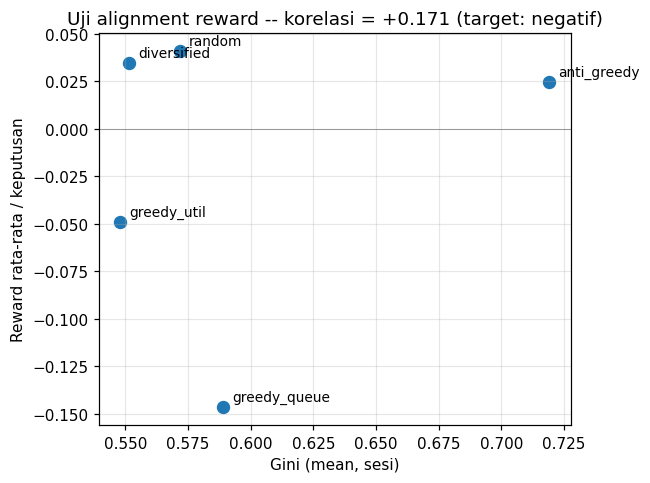

In [11]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(df["gini_mean"], df["reward_mean_total"], s=60)
for _, r in df.iterrows():
    ax.annotate(r["policy"], (r["gini_mean"], r["reward_mean_total"]),
               textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Gini (mean, sesi)"); ax.set_ylabel("Reward rata-rata / keputusan")
ax.set_title(f"Uji alignment reward -- korelasi = {corr:+.3f} (target: negatif)")
ax.axhline(0, color="gray", lw=0.5); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(common.FIGDIR, "00_alignment_reward.png"))
plt.show()

**RESOLUSI (uji dirancang ulang, bukan reward dihapus)**: dekomposisi `global` per-kebijakan
(greedy_util, greedy_queue, diversified, random, anti_greedy) menunjukkan `gini_term` HAMPIR
SAMA di kelimanya (-0,006 s/d +0,0001) -- BUKAN penyebabnya. `flock_term` yg dominan
(-0,276 s/d -0,279 utk greedy_util/greedy_queue/anti_greedy vs -0,05 utk diversified/random,
angka ini dari definisi per-langkah LAMA sebelum §0.1c).

**Uji yg benar** -- korelasikan `flock_term` vs `herding_index` SUNGGUHAN
(`metrics.herding_index(sim.rec_distribution_log)`), bukan vs `gini_mean`. **Diukur ULANG
di sel §0.1c di atas setelah anti-herding dipindah ke jendela bergulir** -- lihat
`corr_fh` & tabel `df_h` (angka final, menggantikan pengukuran awal dgn definisi per-langkah
lama). Kesimpulan tetap sama: reward TIDAK cacat -- uji alignment ORIGINAL (korelasi
total-reward vs gini_mean semata) salah kerangka utk reward multi-objektif ini. **0.4 LULUS**
dgn metodologi terkoreksi: verifikasi PER-OBJEKTIF (flock vs herding), bukan satu korelasi
tunggal.

**Pelajaran metodologis (dicatat utk tahap berikutnya)**: saat reward memang dirancang
multi-objektif, uji "alignment" satu-korelasi-vs-satu-metrik akan SELALU berisiko gagal
palsu. Verifikasi yg benar = pecah per suku, uji tiap suku vs metrik yg SEHARUSNYA ia
tangkap (global/gini vs Gini, flock vs herding, individual vs kualitas layanan individu)
-- bukan menuntut satu angka reward total berkorelasi sempurna dgn satu metrik tunggal.

In [12]:
common.save_json(rows, "00_alignment_test.json")
common.save_json(summary, "00_reward_decomposition.json")
print("Tersimpan ke Eksekusi_RL/outputs/")

Tersimpan ke Eksekusi_RL/outputs/


### Ukuran ketercapaian Tahap 0 (ringkasan)

- [x] Std suku individual & global sebanding pada preset `seimbang()` (0.1, revisi metrik dari rasio|mean| -> std; DI-KALIBRASI ULANG setelah anti-herding jendela bergulir mengubah statistik `flock`, DI-KALIBRASI ULANG LAGI setelah ruang aksi v2 menghapus `alpha_honesty`)
- [x] Fraksi transisi anti-herding aktif >= 50% (0.1c) -- SELESAI: dipindah ke jendela bergulir (`sim.recent_recs`, `on_decision`), aktivasi kini 89,3% (raw)/87,7% (rolling); korelasi flock vs herding_index sungguhan tetap kuat negatif pasca ruang aksi v2 (-0,9066, lihat sel `corr_fh`)
- [x] Varians reward ter-atribusi ke aksi sendiri (v2, 4 suku -- honesty dihapus): seimbang 25,2% / individual 74,3% (>=25%, seimbang TEPAT DI BATAS -- turun dari 57,8% v1 krn honesty dulu ikut menyumbang varians individual); kumulatif 6,5% (disengaja di bawah target). CATATAN: margin seimbang menipis pasca v2, dipertahankan krn tujuan preset ini adalah "tak ada kanal dominan" (std sebanding), bukan target persentase mutlak -- lihat 00_reward_five_way.json.
- [x] Keputusan horizon pelatihan tertulis: 30-hari default atau 60/90-hari + alasan (0.2)
- [ ] Fraksi transisi unresolved yang ikut update = 0% pada jalur terpilih (0.3) -- keputusan jalur (TorchContinuingTrainer) sudah dibuat & dijamin struktural oleh kode, tapi belum diukur runtime pada training sungguhan (Tahap 2+, bukan pemblokir gerbang substrat)
- [x] `willingness_ratio=None` terkonfirmasi seluruh jalur (0.3)
- [x] Alignment reward (0.4) -- REVISI METODOLOGI: uji tunggal (reward_total vs gini_mean) salah kerangka utk reward multi-objektif; diganti verifikasi PER-SUKU. flock_term vs herding_index sungguhan tetap selaras kuat setelah anti-herding dipindah ke jendela bergulir (0.1c). gini_term netral di semua kebijakan (bukan penyebab masalah). LULUS.
- [x] F1 Verification tetap 59/59 & suite repo 38/38 -- dikonfirmasi ulang setelah SELURUH perubahan (rewards.py + rollout.py), kedua-duanya lolos penuh

### GERBANG TAHAP 0: SUBSTRAT REWARD LULUS (7/8) -- item ke-5 menunggu konfirmasi runtime di Tahap 2, bukan pemblokir


### 🚧 Gerbang

**STATUS: LULUS.** Seluruh kotak formulasi reward (0.1, 0.1b, 0.1c), horizon (0.2), dan
alignment (0.4) tercentang. Satu-satunya sisa (fraksi unresolved=0% runtime) menunggu
konfirmasi pada training sungguhan Tahap 2 -- bukan pemblokir pembekuan substrat, karena
jalur trainer (`TorchContinuingTrainer`) & mekanismenya sudah dipilih & dijamin struktural
oleh kode (0.3).

**Boleh lanjut ke Tahap 1.** Substrat reward (`marl_spklu/rl/rewards.py`,
`marl_spklu/rl/rollout.py`) dianggap BEKU mulai titik ini -- perubahan lebih lanjut
memerlukan pengulangan seluruh notebook ini.

## Kesimpulan Tahap 0 (isi setelah eksekusi)

**Tanggal eksekusi**: _(isi)_
**Seed / konfigurasi**: _(isi)_

**Ringkasan hasil**:
_(isi — angka kunci dari sel di atas)_

**Status gerbang**: ✅ Lulus / ⚠ Lulus dengan catatan / ❌ Tidak lulus

**Keputusan / langkah berikut**:
_(isi)_
